In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [2]:
df = pd.read_sql(
    'SELECT * FROM "Public_water_supplys";',
    engine
)
df

,Id,Year,Total,Abstracted_water,Ground_water,Springs,Watercourse,Reservoir,Lake,Water_taken_from_other_water_supply_systems
0,1,2017,277468.998,264601.423,43438.402,160588.729,32720.281,17514.011,10340.000,12867.575
1,2,2018,305430.052,291494.883,34543.132,197802.545,32053.962,23879.244,3216.000,13935.169
2,3,2019,303911.482,291727.006,35323.713,188883.316,33007.389,31516.011,2996.577,12184.476
3,4,2020,313013.351,301540.545,38491.107,192322.795,36888.247,31360.411,2477.985,11472.806
4,5,2021,306259.258,294264.556,37490.054,192957.919,29998.807,31311.009,2506.767,11994.702
5,6,2022,300115.986,289171.440,42418.505,184410.861,28740.132,31031.869,2570.073,10944.546
6,7,2023,293191.071,282473.379,41796.262,178955.431,28690.888,30095.159,2935.639,10717.692
7,8,2024,306648.504,289524.094,56205.182,174692.080,20119.041,35586.325,2921.466,17124.410


In [30]:
df = df.drop(columns=["Id"])
columns_to_model = df.columns.drop("Year")
future_years = pd.DataFrame({"Year": [2025, 2026, 2027, 2028]})

In [31]:
import os

os.makedirs("../models/Public_water_supplies", exist_ok=True)
forecasts = {}
best_degrees = {}

In [32]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import joblib


tscv = TimeSeriesSplit(n_splits=3)
degrees = [1, 2, 3]

for col in columns_to_model:
    X = df[["Year"]]
    y = df[col]

    pipeline = make_pipeline(PolynomialFeatures(), LinearRegression())
    param_grid = {"polynomialfeatures__degree": degrees}

    grid = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='neg_mean_squared_error')
    grid.fit(X, y)

    best_model = grid.best_estimator_
    best_degree = grid.best_params_['polynomialfeatures__degree']
    best_degrees[col] = best_degree

    pred = best_model.predict(future_years)
    forecasts[col] = pred

    model_path = f"../models/Public_water_supplies/{col}_poly_model.pkl"
    joblib.dump(best_model, model_path)

df_forecast = pd.DataFrame(forecasts, index=future_years["Year"])
print(df_forecast)

print("\nBest polynomial degrees per column:")
for col, deg in best_degrees.items():
    print(f"{col}: degree={deg}")

              Total  Abstracted_water  Ground_water        Springs  \
Year                                                                 
2025  307447.037179     270222.088242  49030.246393  183382.369107   
2026  308934.192607     255579.691571  50767.346786  183283.626798   
2027  310421.348036     237736.414401  52504.447179  183184.884488   
2028  311908.503464     216692.256730  54241.547571  183086.142179   

       Watercourse     Reservoir         Lake  \
Year                                            
2025  23596.168679  37398.394786   821.513036   
2026  22111.463190  39256.536988   171.724071   
2027  20626.757702  41114.679190  -478.064893   
2028  19142.052214  42972.821393 -1127.853857   

      Water_taken_from_other_water_supply_systems  
Year                                               
2025                                 13218.345179  
2026                                 13343.494774  
2027                                 13468.644369  
2028                    

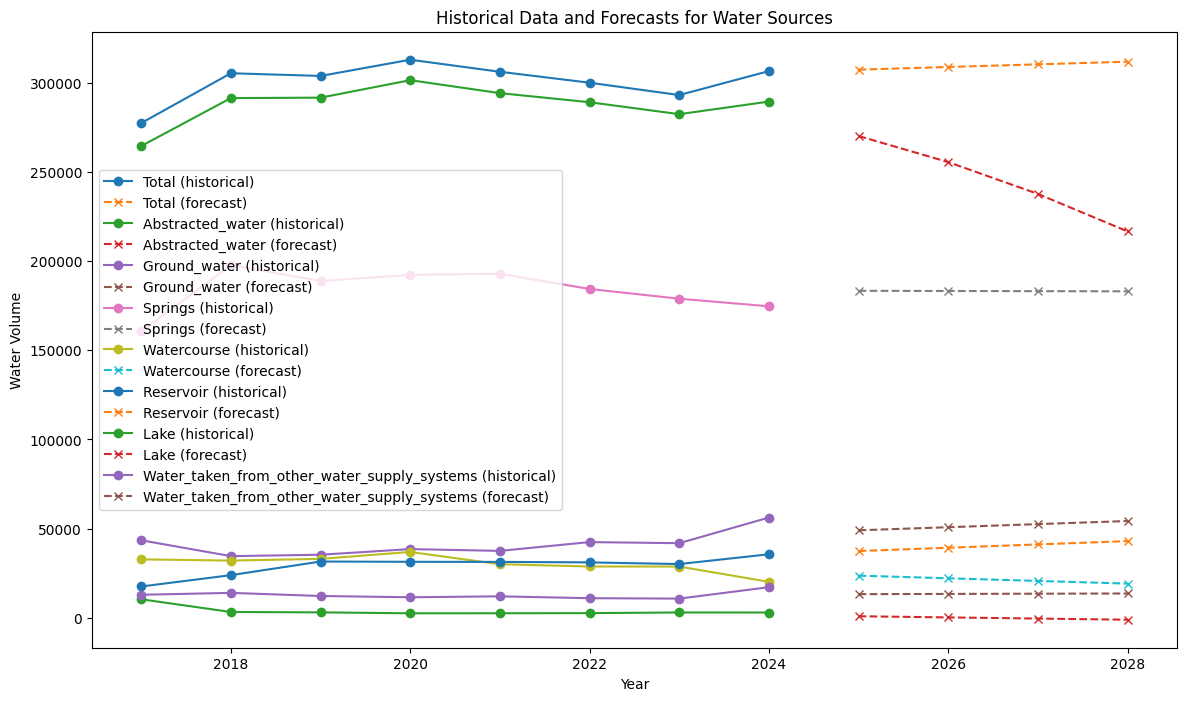

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
for col in columns_to_model:
    plt.plot(df["Year"], df[col], label=f"{col} (historical)", marker='o')
    plt.plot(df_forecast.index, df_forecast[col], label=f"{col} (forecast)", linestyle='--', marker='x')
plt.xlabel("Year")
plt.ylabel("Water Volume")
plt.title("Historical Data and Forecasts for Water Sources")
plt.legend()
plt.show()

<Axes: >

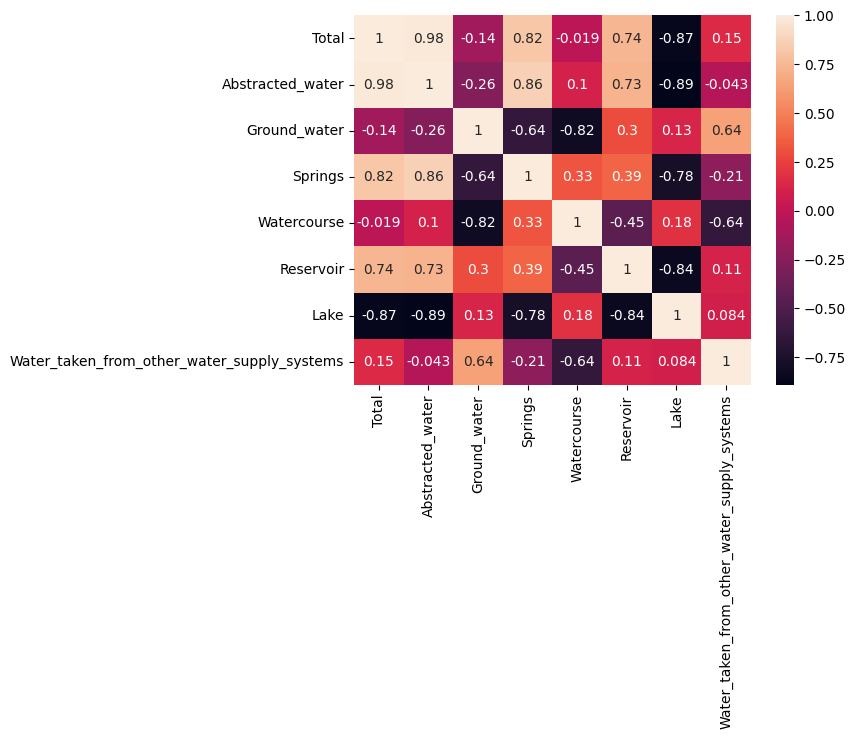

In [34]:
import seaborn as sns

sns.heatmap(df[columns_to_model].corr(), annot=True)